In [52]:
import pandas as pd
import numpy as np

In [53]:
df = pd.read_csv(r"C:\Users\srija\OneDrive\Desktop\machine learning\DEEP LEARNING\datasets\powerplant_data.csv")

In [54]:
df.head(5)
# AT - temperature value
# V - vaccum
# AO - Pressure
# RH - Humidity

# PE - Prouduce Energy

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [55]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [56]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [57]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [58]:
# Training in Neural network
# 1. Load the Dataset
# 2. Data convert to Tensors
# 3. TensorDataset and DataLoader
# 4. Define ANN model  
# 5. Train the model (save the model too)
# 6. Evaluation

In [59]:
# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1 ,1)
# y_train.values because, its a pandas core series not a numpy array
# .view(-1, 1) because its only has one column.

In [62]:
# Data Loader - to define how the data will be loaded for training
# - creates batches for us
# - shuffles (optional )
# Tensor Dataset class - it recives raw data, and transfer it to Data Loader(DL cant access raw data from memory).
# - access data
# - can access one sample / one row(features, target)

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [63]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Deep Learning

In [64]:
# Defined Artificial Neural Network Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd Hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            #output layer
            nn.Linear(6, 1),
        )

    def forward(self, x):
        return self.model(x)


# No need to write backward propagation.

In [65]:
import torch.optim as optim

model = ANN()

# Loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [66]:
# Train the ANN

train_loss = []
val_losses = []

best_val_loss = float("inf")

epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # trainig loss for 1 epoch

    for xb, yb, in train_loader:
        #xb - features of 1 batch
        #yb - labels of 1 batch

        optimizer.zero_grad() # Fresh gradients repeatedly

        # 1. forward Propagation.
        outputs = model(xb) # Predicted outputs for this batch

        # 2. compute loss.
        loss = criterion(outputs, yb)

        # 3. backward propagation
        loss.backward()

        # 4. update parameters
        optimizer.step()

        # running loss - for all the batches.
        running_loss += loss.item() # convert tensor to float values with .items()
    
    epoch_train_loss  = running_loss / len(train_loader)
    train_loss.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # so that gradient is not computed
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") # .pt or .pth
 

Epoch 1/100 | Train Loss: 205689.7831 | Val Loss: 203217.9333
Epoch 2/100 | Train Loss: 194583.3505 | Val Loss: 180576.5492
Epoch 3/100 | Train Loss: 156339.1744 | Val Loss: 128030.3467
Epoch 4/100 | Train Loss: 97125.9720 | Val Loss: 68837.2938
Epoch 5/100 | Train Loss: 48210.1580 | Val Loss: 32814.4593
Epoch 6/100 | Train Loss: 23943.5000 | Val Loss: 17752.7133
Epoch 7/100 | Train Loss: 14468.2817 | Val Loss: 12165.3488
Epoch 8/100 | Train Loss: 10714.8095 | Val Loss: 9434.6272
Epoch 9/100 | Train Loss: 8421.4351 | Val Loss: 7358.5177
Epoch 10/100 | Train Loss: 6503.4078 | Val Loss: 5622.9077
Epoch 11/100 | Train Loss: 4892.6251 | Val Loss: 4196.5791
Epoch 12/100 | Train Loss: 3575.8081 | Val Loss: 3052.7548
Epoch 13/100 | Train Loss: 2554.3592 | Val Loss: 2181.4633
Epoch 14/100 | Train Loss: 1797.2336 | Val Loss: 1538.4077
Epoch 15/100 | Train Loss: 1251.0622 | Val Loss: 1083.7933
Epoch 16/100 | Train Loss: 875.1561 | Val Loss: 769.5638
Epoch 17/100 | Train Loss: 622.1675 | Val Loss

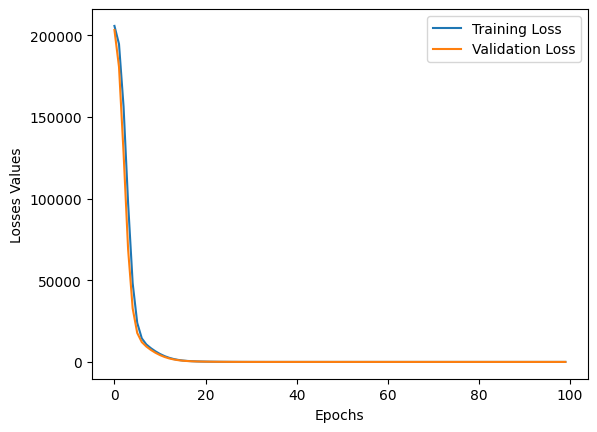

In [67]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training loss": train_loss,
    "Validation loss": val_losses 
})

plt.plot(loss_df["Training loss"], label = "Training Loss")
plt.plot(loss_df["Validation loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses Values")
plt.legend()

In [70]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))
# model contains value with best_val_loss

<All keys matched successfully>

In [74]:
# Evaluating the model
# Steps:
# Training MSE
# Testing MSE
# R2 - R2 Score

model.eval()
with torch.no_grad():
    train_predict = model(X_train_tensor)
    test_predict = model(X_test_tensor)

    train_mse_loss = criterion(train_predict, y_train_tensor)
    test_mse_loss = criterion(test_predict, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 21.18776512145996
Testing MSE: 19.524911880493164


In [75]:
from sklearn.metrics import r2_score

print("R^2 Score: ", r2_score(y_test, test_predict))

R^2 Score:  0.9317654801164873


In [76]:
predicted_df = pd.DataFrame(test_predict.numpy(), columns=["Predicted Value"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Value,Actual Values
0,435.523743,433.27
1,437.251801,438.16
2,460.981293,458.42
3,475.711700,480.82
4,435.684113,441.41
...,...,...
1909,451.201447,456.70
1910,431.978973,438.04
1911,467.320343,467.80
1912,431.484436,437.14
